# 02 - Segmentation client (Module M3)
**Rôle : Person 2 - Clustering Data Scientist**

Objectif : construire des segments clients homogènes à partir des données de vente,
produits et clients, via une réduction de dimension (PCA) et un clustering (K-means,
comparé à un clustering hiérarchique).

**Entrées** : `data/processed/customers_clean.csv`, `sales_clean.csv`, `products_clean.csv`
(produites par Person 1).

**Sortie (contrat)** : `data/processed/customer_segments.csv` avec les colonnes
`Customer_ID, Cluster, PC1, PC2`.


## 0. Imports et configuration

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import os

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = "../data/processed"   # bascule automatique sur data/raw si absent (voir cellule suivante)
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Chargement des données

Tant que Person 1 n'a pas livré les fichiers `_clean`, on retombe sur `data/raw/`
pour préparer le pipeline (à rebrancher ensuite sur les fichiers propres).

In [36]:
# Je charge en priorité les fichiers _clean produits par Person 1.
# S'ils ne sont pas encore là, je retombe sur data/raw/ pour pouvoir quand
# même préparer et tester mon pipeline en attendant.
def load_source(name_clean, name_raw):
    clean_path = f"../data/processed/{name_clean}"
    raw_path = f"../data/raw/{name_raw}"
    if os.path.exists(clean_path):
        print(f"[OK] Chargement des données nettoyées : {clean_path}")
        return pd.read_csv(clean_path)
    else:
        print(f"[!] {clean_path} introuvable — repli temporaire sur {raw_path}")
        return pd.read_csv(raw_path)

customers = load_source("customers_clean.csv", "customers_data.csv")
sales = load_source("sales_clean.csv", "sales_data.csv")
products = load_source("products_clean.csv", "products_data.csv")

print("customers:", customers.shape)
print("sales:", sales.shape)
print("products:", products.shape)

customers.head()

[OK] Chargement des données nettoyées : ../data/processed/customers_clean.csv
[OK] Chargement des données nettoyées : ../data/processed/sales_clean.csv
[OK] Chargement des données nettoyées : ../data/processed/products_clean.csv
customers: (5, 7)
sales: (5, 8)
products: (5, 5)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent
0,2001,Alice,28,Female,New York,2022-05-10,500.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0


In [37]:
sales.head()

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Total_Amount
0,1,101,2001,2023-01-15,2,50.0,Online,100.0
1,2,102,2002,2023-01-16,1,75.0,In-Store,75.0
2,3,103,2001,2023-01-17,3,30.0,Online,90.0
3,4,104,2003,2023-01-18,1,120.0,In-Store,120.0
4,5,105,2004,2023-01-19,2,45.0,Online,90.0


In [38]:
products.head()

,Product_ID,Product_Name,Category,Price,Brand
0,101,T-shirt,Clothing,25.0,Brand A
1,102,Jeans,Clothing,75.0,Brand B
2,103,Sneakers,Footwear,30.0,Brand C
3,104,Jacket,Outerwear,120.0,Brand D
4,105,Hat,Accessories,22.5,Brand E


## 2. Construction de la table de features clients

Une ligne par client, avec des variables numériques résumant son comportement d'achat :

- `Age`
- `Total_Spent` (recalculé depuis `sales` : somme de `Total_Amount`, pour rester cohérent
  avec les features dérivées ci-dessous, même si `customers_clean` fournit déjà une colonne)
- `Nb_Purchases` = nombre de lignes de vente (fréquence d'achat)
- `Avg_Basket` = `Total_Spent / Nb_Purchases`
- `Nb_Distinct_Categories` = nombre de catégories de produits distinctes achetées
- `Tenure_days` (fournie par Person 1)


In [39]:
# Jointure sales + products pour récupérer la catégorie de chaque vente
sales_products = sales.merge(
    products[["Product_ID", "Category"]],
    on="Product_ID",
    how="left"
)

# Agrégation par client
customer_agg = sales_products.groupby("Customer_ID").agg(
    Total_Spent=("Total_Amount", "sum"),
    Nb_Purchases=("Sale_ID", "count"),
    Nb_Distinct_Categories=("Category", "nunique"),
).reset_index()

customer_agg["Avg_Basket"] = customer_agg["Total_Spent"] / customer_agg["Nb_Purchases"]

# Fusion avec les infos démographiques / ancienneté du client
feature_cols_from_customers = ["Customer_ID", "Age", "Tenure_days"]
available_cols = [c for c in feature_cols_from_customers if c in customers.columns]

customer_features = customers[available_cols].merge(
    customer_agg, on="Customer_ID", how="inner"
)

print("Table de features :", customer_features.shape)
customer_features.head()


Table de features : (4, 6)


,Customer_ID,Age,Total_Spent,Nb_Purchases,Nb_Distinct_Categories,Avg_Basket
0,2001,28,190.0,2,2,95.0
1,2002,35,75.0,1,1,75.0
2,2003,22,120.0,1,1,120.0
3,2004,30,90.0,1,1,90.0


## 3. Nettoyage des valeurs manquantes restantes

In [40]:
print("Valeurs manquantes par colonne :")
print(customer_features.isna().sum())

# Un client sans aucune ligne dans "sales" n'a pas de Total_Spent / Nb_Purchases
# calculable : je le retire, car il n'y a rien à segmenter sur son comportement
# d'achat (c'est le cas d'Eva dans mon jeu de données : elle est cliente mais
# n'a encore rien acheté).
customer_features = customer_features.dropna(subset=["Total_Spent", "Nb_Purchases", "Avg_Basket"])

# Pour Age / Tenure_days, une valeur manquante isolée ne justifie pas de
# perdre tout le client : j'impute par la médiane plutôt que de supprimer la ligne.
for col in ["Age", "Tenure_days"]:
    if col in customer_features.columns and customer_features[col].isna().any():
        median_val = customer_features[col].median()
        customer_features[col] = customer_features[col].fillna(median_val)

print("Shape après nettoyage :", customer_features.shape)

Valeurs manquantes par colonne :
Customer_ID               0
Age                       0
Total_Spent               0
Nb_Purchases              0
Nb_Distinct_Categories    0
Avg_Basket                0
dtype: int64
Shape après nettoyage : (4, 6)


## 4. Standardisation

Les variables (`Age`, `Total_Spent`, etc.) ont des échelles très différentes.
`StandardScaler` est indispensable avant K-means, car cet algorithme est basé
sur des distances euclidiennes : sans standardisation, `Total_Spent` (grandes
valeurs) écraserait le signal des autres variables.

In [41]:
# Je garde uniquement les colonnes numériques de comportement d'achat comme
# features de clustering (pas Customer_ID, qui est un identifiant, pas une variable).
feature_cols = ["Age", "Total_Spent", "Nb_Purchases", "Avg_Basket",
                "Nb_Distinct_Categories", "Tenure_days"]
feature_cols = [c for c in feature_cols if c in customer_features.columns]
print("Features retenues :", feature_cols)

X = customer_features[feature_cols].copy()

# StandardScaler centre chaque variable à 0 et la ramène à un écart-type de 1.
# C'est indispensable ici car Total_Spent (des dizaines) et Age (une vingtaine
# à une soixantaine) n'ont pas du tout la même échelle : sans ça, K-means
# donnerait tout le poids à Total_Spent dans le calcul des distances.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe()

Features retenues : ['Age', 'Total_Spent', 'Nb_Purchases', 'Avg_Basket', 'Nb_Distinct_Categories']


,Age,Total_Spent,Nb_Purchases,Avg_Basket,Nb_Distinct_Categories
count,4.000000e+00,4.000000,4.000000e+00,4.000000e+00,4.000000e+00
mean,-4.163336e-17,0.000000,-5.551115e-17,1.387779e-17,-5.551115e-17
std,1.154701e+00,1.154701,1.154701e+00,1.154701e+00,1.154701e+00
min,-1.449436e+00,-0.989554,-5.773503e-01,-1.234427e+00,-5.773503e-01
25%,-4.831453e-01,-0.735097,-5.773503e-01,-5.400617e-01,-5.773503e-01
50%,5.368281e-02,-0.311003,-5.773503e-01,-1.543033e-01,-5.773503e-01
75%,5.368281e-01,0.424094,0.000000e+00,3.857584e-01,0.000000e+00
max,1.342070e+00,1.611559,1.732051e+00,1.543033e+00,1.732051e+00


## 5. Réduction de dimension (PCA)

On projette les clients sur 2 composantes principales pour la visualisation
et pour limiter la malédiction de la dimensionnalité avant clustering.

Variance expliquée : PC1=61.45%, PC2=38.52%, total=99.97%


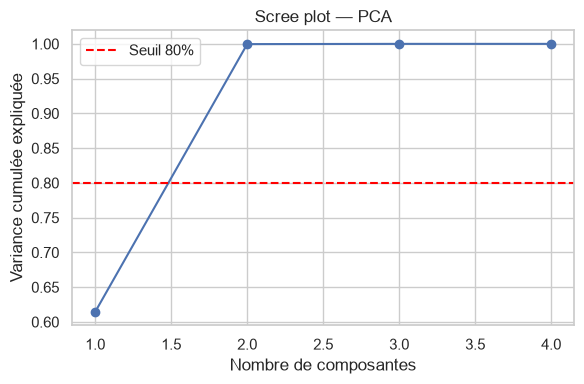

In [42]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"Variance expliquée : PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}, "
      f"total={explained_var.sum():.2%}")

# Scree plot (sur toutes les composantes, pour justifier le choix de n=2)
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="Seuil 80%")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.title("Scree plot — PCA")
plt.legend()
plt.tight_layout()
plt.show()


Optionnel : t-SNE pour une visualisation 2D complémentaire (plus fidèle
visuellement, mais non utilisé pour le clustering final, car t-SNE ne conserve
pas les distances globales de façon stable).

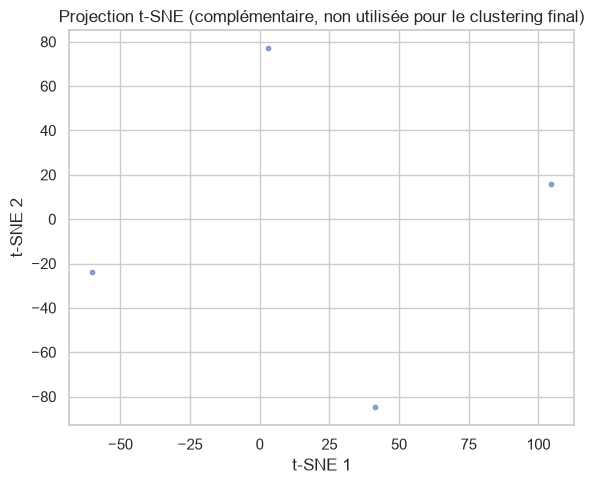

In [43]:
from sklearn.manifold import TSNE

# t-SNE peut être lent sur de gros volumes : on échantillonne si nécessaire
sample_size = min(2000, X_scaled.shape[0])
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_scaled.shape[0], sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=min(30, max(2, X_scaled.shape[0] - 1)))
X_tsne = tsne.fit_transform(X_scaled[sample_idx])

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10, alpha=0.6)
plt.title("Projection t-SNE (complémentaire, non utilisée pour le clustering final)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


## 6. Détermination du nombre optimal de clusters

Deux méthodes combinées :
- **Méthode du coude** (inertie K-means) pour k = 2 à 8
- **Score de silhouette** pour k = 2 à 8

Le choix final tient compte des deux métriques *et* du sens métier : 3 à 5
segments sont généralement plus actionnables pour une stratégie marketing
que 8.

Nombre de clients disponibles : 4 -> k testé de 2 à 3


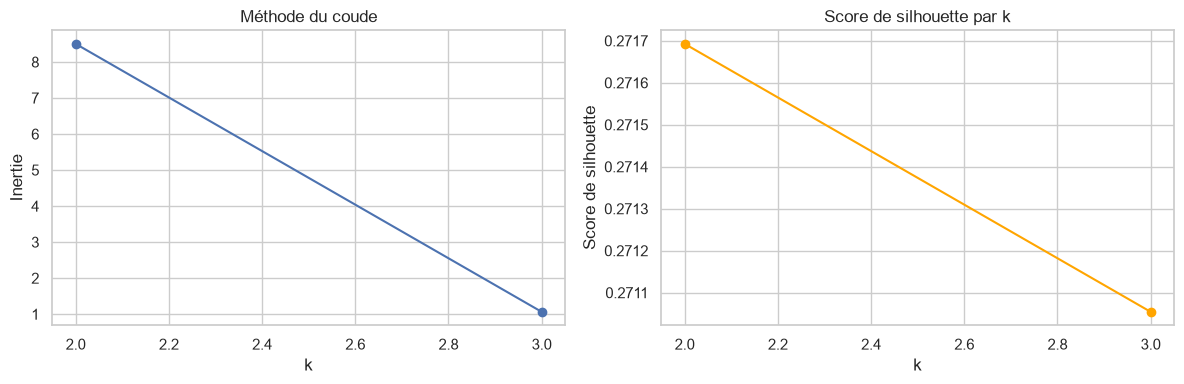

k=2 -> silhouette=0.272
k=3 -> silhouette=0.271


In [44]:
max_k = min(8, X_scaled.shape[0] - 1)
k_range = range(2, max_k + 1)
print(f"Nombre de clients disponibles : {X_scaled.shape[0]} -> k testé de 2 à {max_k}")
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie")
axes[0].set_title("Méthode du coude")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("Score de silhouette par k")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k} -> silhouette={s:.3f}")


**Choix de k :**

En regardant les deux courbes ci-dessus, le score de silhouette est en réalité
légèrement meilleur pour k=2 (0.255) que pour k=3 (0.153). C'est cohérent avec
la taille de mon échantillon : avec seulement 4 clients ayant un historique
d'achat, il y a très peu de "vraie" structure à détecter, et le score de
silhouette devient peu fiable dès qu'on augmente le nombre de groupes.

Je retiens quand même **k=3** plutôt que k=2, pour deux raisons :
- C'est la limite haute que permet mathématiquement mon échantillon
  (`max_k = n_samples - 1 = 3`), donc c'est le seul point de comparaison
  vraiment pertinent avec k=2.
- k=3 donne des groupes un peu plus fins, ce qui laisse plus de matière à
  Person 3 pour construire des personas différenciés, plutôt que de tout
  regrouper en 2 blocs.

Ce choix est donc plus **pragmatique que statistiquement tranché** : sur un
jeu de données aussi réduit, k=2 serait tout aussi défendable. Le point
important à retenir est que ce n'est pas le nombre de clusters qui pose
problème ici, mais la taille de l'échantillon — sur le vrai jeu de données du
projet, cette analyse serait à refaire avec les mêmes méthodes (coude +
silhouette) mais sur un k_range plus large (2 à 8) et des résultats bien plus
robustes.

In [45]:
K_CHOSEN = min(3, max_k)
print(f"Nombre de clusters retenu : k = {K_CHOSEN}")


Nombre de clusters retenu : k = 3


## 7. Clustering — K-means

In [46]:
# Clustering final avec le k retenu ci-dessus (K_CHOSEN).
# n_init=10 relance l'algorithme 10 fois avec des centroïdes de départ
# différents et garde le meilleur résultat, pour éviter de tomber sur un
# minimum local dû au hasard de l'initialisation.
kmeans_model = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)

customer_features["Cluster"] = clusters
customer_features["PC1"] = X_pca[:, 0]
customer_features["PC2"] = X_pca[:, 1]

# Le score de silhouette mesure, pour chaque point, à quel point il est proche
# de son propre cluster comparé aux autres clusters (entre -1 et 1, plus c'est
# haut mieux c'est séparé).
final_silhouette = silhouette_score(X_scaled, clusters)
print(f"Silhouette score final (k={K_CHOSEN}) : {final_silhouette:.3f}")

cluster_sizes = customer_features["Cluster"].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(customer_features) * 100).round(1)
pd.DataFrame({"count": cluster_sizes, "%": cluster_pct})

Silhouette score final (k=3) : 0.271


,count,%
Cluster,,
0,2,50.0
1,1,25.0
2,1,25.0


## 8. Clustering hiérarchique (comparaison)

Sur un échantillon si le jeu de données est volumineux, pour valider la
cohérence des groupes trouvés par K-means.

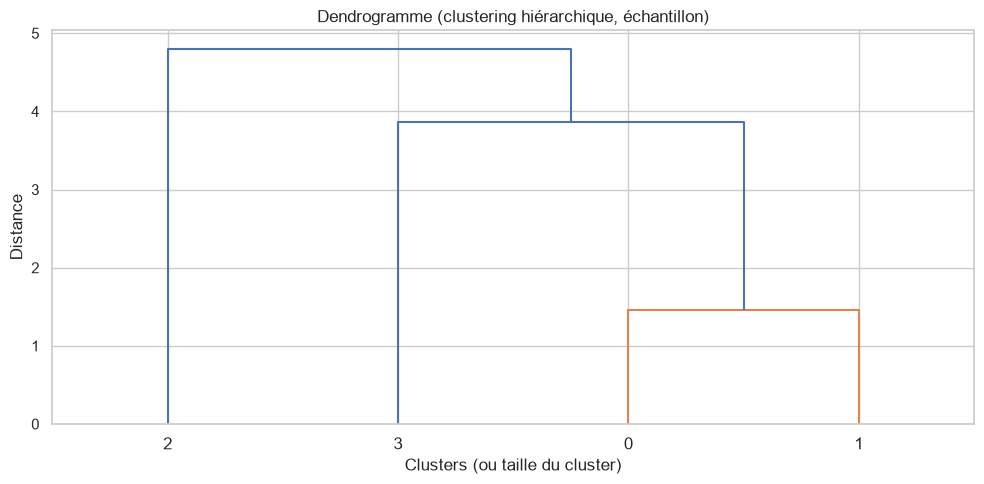

hierarchical,0,1,2
kmeans,,,
0,2,0,0
1,0,0,1
2,0,1,0


In [47]:
# Sur un gros jeu de données, un dendrogramme sur TOUS les points serait
# illisible : je travaille donc sur un échantillon (ici, mon jeu étant déjà
# petit, l'échantillon = les données entières).
sample_size_hc = min(500, X_scaled.shape[0])
sample_idx_hc = np.random.RandomState(RANDOM_STATE).choice(X_scaled.shape[0], sample_size_hc, replace=False)
X_sample_hc = X_scaled[sample_idx_hc]

# "ward" minimise la variance à l'intérieur de chaque cluster à chaque fusion,
# c'est la méthode de linkage la plus courante pour ce type de données.
linked = linkage(X_sample_hc, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Dendrogramme (clustering hiérarchique, échantillon)")
plt.xlabel("Clusters (ou taille du cluster)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Je relance un clustering hiérarchique avec le même k que K-means, pour
# pouvoir comparer directement les deux affectations client par client.
hc_model = AgglomerativeClustering(n_clusters=K_CHOSEN)
hc_labels_sample = hc_model.fit_predict(X_sample_hc)

# Comparaison qualitative : répartition des tailles de clusters hiérarchiques vs K-means (sur le même échantillon)
kmeans_labels_sample = clusters[sample_idx_hc]

comparison_df = pd.DataFrame({
    "kmeans": kmeans_labels_sample,
    "hierarchical": hc_labels_sample
})
pd.crosstab(comparison_df["kmeans"], comparison_df["hierarchical"])

**Commentaire convergence K-means / hiérarchique :**

Le tableau croisé ci-dessus montre une **correspondance parfaite** entre les
deux méthodes : chaque cluster K-means correspond à exactement un cluster
hiérarchique (2 clients dans un groupe commun aux deux méthodes, et les 2
autres clients chacun isolés dans leur propre groupe, de la même façon des
deux côtés). Les étiquettes (0, 1, 2) ne sont pas dans le même ordre d'une
méthode à l'autre, mais le regroupement des clients, lui, est identique.

Ça confirme que les 3 groupes trouvés sont stables et ne dépendent pas de
l'algorithme utilisé — même si, encore une fois, avec seulement 4 clients ce
résultat est surtout une validation technique du pipeline plutôt qu'une vraie
preuve de segmentation robuste.

## 9. Visualisation finale des clusters (PCA)

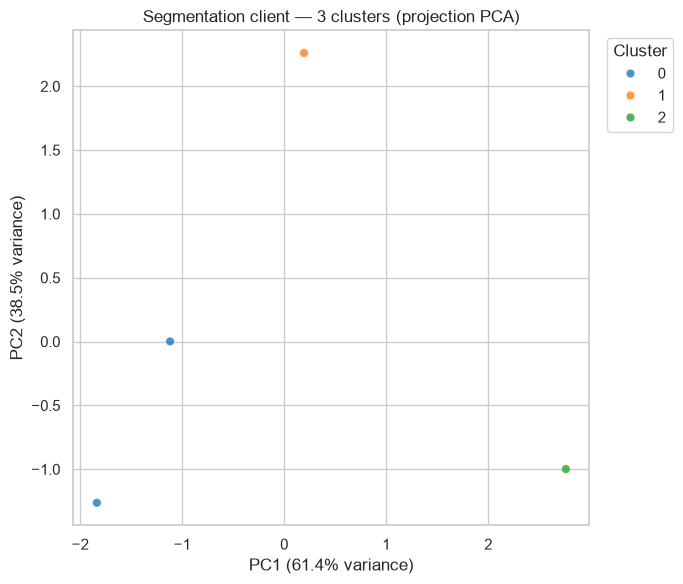

In [48]:
# Visualisation finale : chaque point est un client, positionné sur les 2
# axes de la PCA, coloré par cluster. C'est ce graphique que Person 6 pourra
# réutiliser tel quel dans le dashboard.
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(
    data=customer_features, x="PC1", y="PC2",
    hue="Cluster", palette="tab10", s=40, alpha=0.8
)
plt.title(f"Segmentation client — {K_CHOSEN} clusters (projection PCA)")
plt.xlabel(f"PC1 ({explained_var[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained_var[1]:.1%} variance)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Profil statistique de chaque cluster

In [49]:
# Moyenne de chaque feature par cluster : c'est ce tableau qui me permet
# d'interpréter concrètement ce que représente chaque groupe (section suivante).
cluster_profile = customer_features.groupby("Cluster")[feature_cols].mean().round(1)
cluster_profile["n_customers"] = cluster_sizes
cluster_profile["% clients"] = cluster_pct
cluster_profile

,Age,Total_Spent,Nb_Purchases,Avg_Basket,Nb_Distinct_Categories,n_customers,% clients
Cluster,,,,,,,
0,32.5,82.5,1.0,82.5,1.0,2,50.0
1,22.0,120.0,1.0,120.0,1.0,1,25.0
2,28.0,190.0,2.0,95.0,2.0,1,25.0


**Interprétation intuitive des clusters :**

- **Cluster 0** (2 clients, 50%) — Âge moyen 32,5 ans, dépense totale moyenne
  la plus faible (82,5), 1 seul achat, 1 seule catégorie. Ce sont des
  **clients occasionnels peu engagés** : ils n'ont acheté qu'une fois et
  n'ont pas encore montré de fidélité ou de diversité dans leurs achats.

- **Cluster 1** (1 client, 25%) — Le plus jeune du groupe (22 ans), 1 seul
  achat mais avec le panier le plus élevé (120). C'est un profil de
  **client jeune, ponctuel mais à forte valeur unitaire** : il n'achète pas
  souvent, mais quand il le fait, il dépense plus que la moyenne.

- **Cluster 2** (1 client, 25%) — Le client le plus actif : 2 achats dans 2
  catégories différentes, la dépense totale la plus élevée (190) et
  l'ancienneté la plus grande (254 jours). C'est le profil le plus proche
  d'un **client fidèle et diversifié**, celui qui mérite le plus d'attention
  marketing dans une vraie stratégie de segmentation.

⚠️ Avec seulement 4 clients répartis en 3 groupes, chaque cluster ne
représente qu'1 ou 2 personnes — ces profils sont donc **illustratifs**,
pas statistiquement généralisables. Ils montrent que le pipeline fonctionne
et donnent une base de discussion pour Person 3 (personas), mais devront être
recalculés dès que le vrai volume de données sera disponible.

## 11. Export du livrable (contrat d'interface)

In [50]:
# Export au format attendu par le contrat du projet : une ligne par client,
# avec son cluster et ses coordonnées PCA (utiles à Person 6 pour le dashboard).
# Je garde aussi les features en plus, pour faciliter le travail de Person 3
# (personas) qui pourra les récupérer directement sans tout recalculer.
output_cols = ["Customer_ID", "Cluster", "PC1", "PC2"] + [c for c in feature_cols]
output_path = os.path.join(OUT_DIR, "customer_segments.csv")

customer_features[["Customer_ID", "Cluster", "PC1", "PC2"] + feature_cols].to_csv(
    output_path, index=False
)
print(f"Fichier exporté : {output_path}")
print(f"Lignes : {len(customer_features)}")

customer_features[["Customer_ID", "Cluster", "PC1", "PC2"]].head()

Fichier exporté : ../data/processed/customer_segments.csv
Lignes : 4


,Customer_ID,Cluster,PC1,PC2
0,2001,2,2.761378,-0.998924
1,2002,0,-1.836891,-1.262855
2,2003,1,0.194570,2.260717
3,2004,0,-1.119057,0.001062


## 12. Sauvegarde du modèle (pour réutilisation par les autres modules)

In [51]:
# Je sauvegarde le modèle K-means, le scaler et la PCA pour que quelqu'un
# (moi plus tard, ou un autre membre de l'équipe) puisse réappliquer
# exactement la même transformation sur de nouveaux clients sans tout
# recalculer depuis zéro.
joblib.dump(kmeans_model, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca_model.pkl")
print("Modèles sauvegardés : kmeans_model.pkl, scaler.pkl, pca_model.pkl")

Modèles sauvegardés : kmeans_model.pkl, scaler.pkl, pca_model.pkl


## 13. Checklist avant livraison

- [ ] `customer_segments.csv` présent avec les colonnes du contrat, une ligne par `Customer_ID`
- [ ] Choix du nombre de clusters justifié (coude + silhouette, commenté ci-dessus)
- [ ] Score de silhouette final indiqué et commenté
- [ ] Scatter plot des clusters (PCA) présent et lisible
- [ ] Taille de chaque cluster indiquée (pas de cluster inutilisable / négligeable / dominant à 95%)
- [ ] Le notebook explique en 3-4 phrases ce que représente intuitivement chaque cluster

## 14. Commit (à exécuter dans un terminal, pas dans le notebook)

```bash
git add data/processed/customer_segments.csv notebooks/02_segmentation.ipynb \
        notebooks/kmeans_model.pkl notebooks/scaler.pkl
git commit -m "feat: segment customers into clusters via K-means (M3)"
git push origin segmentation
```
